In [ ]:
!pip -q install dexpy

import numpy as np
import pandas as pd
import dexpy.factorial
import dexpy.design
import dexpy.optimal
from dexpy.model import ModelOrder
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done


part a

ai

In [ ]:
coffee_design_5_2 = dexpy.factorial.build_factorial(5, 2**(5-2))
coffee_design_5_2.columns = ['amount','grind_size','brew_time','grind_type','beans']

print("Antal experiment:", len(coffee_design_5_2))
coffee_design_5_2

Antal experiment: 8


,amount,grind_size,brew_time,grind_type,beans
0,-1,-1,-1,1,1
1,-1,-1,1,1,-1
2,-1,1,-1,-1,1
3,-1,1,1,-1,-1
4,1,-1,-1,-1,-1
5,1,-1,1,-1,1
6,1,1,-1,1,-1
7,1,1,1,1,1


aii

In [ ]:
coffee_design = dexpy.factorial.build_factorial(5, 2**(5-1))
coffee_design.columns = ['amount','grind_size','brew_time','grind_type','beans']

center_points = [
    [0,0,0,-1,-1],
    [0,0,0,-1, 1],
    [0,0,0, 1,-1],
    [0,0,0, 1, 1]
]

coffee_design = pd.concat(
    [coffee_design, pd.DataFrame(center_points*2, columns=coffee_design.columns)],
    ignore_index=True
)

print("Antal experiment:", len(coffee_design))
coffee_design

Antal experiment: 24


,amount,grind_size,brew_time,grind_type,beans
0,-1,-1,-1,-1,1
1,-1,-1,-1,1,-1
2,-1,-1,1,-1,-1
3,-1,-1,1,1,1
4,-1,1,-1,-1,-1
5,-1,1,-1,1,1
6,-1,1,1,-1,1
7,-1,1,1,1,-1
8,1,-1,-1,-1,-1
9,1,-1,-1,1,1


In [ ]:
actual_lows = {'amount': 2.5, 'grind_size': 8,  'brew_time': 3.5, 'grind_type': 'burr',  'beans': 'light'}
actual_highs= {'amount': 4.0, 'grind_size': 10, 'brew_time': 4.5, 'grind_type': 'blade', 'beans': 'dark'}

actual_design = dexpy.design.coded_to_actual(coffee_design, actual_lows, actual_highs)
actual_design

,amount,grind_size,brew_time,grind_type,beans
0,2.50,8.0,3.5,burr,dark
1,2.50,8.0,3.5,blade,light
2,2.50,8.0,4.5,burr,light
3,2.50,8.0,4.5,blade,dark
4,2.50,10.0,3.5,burr,light
5,2.50,10.0,3.5,blade,dark
6,2.50,10.0,4.5,burr,dark
7,2.50,10.0,4.5,blade,light
8,4.00,8.0,3.5,burr,light
9,4.00,8.0,3.5,blade,dark


a2

In [ ]:
coffee_design['taste_rating'] = [
    4.4, 2.6, 2.4, 8.6, 1.6, 2.8, 7.2, 3.4,
    6.8, 3.4, 3.8, 9.0, 5.2, 3.6, 8.2, 7.0,
    5.4, 6.8, 3.6, 5.4, 4.8, 6.2, 4.4, 5.8
]

coffee_design

,amount,grind_size,brew_time,grind_type,beans,taste_rating
0,-1,-1,-1,-1,1,4.4
1,-1,-1,-1,1,-1,2.6
2,-1,-1,1,-1,-1,2.4
3,-1,-1,1,1,1,8.6
4,-1,1,-1,-1,-1,1.6
5,-1,1,-1,1,1,2.8
6,-1,1,1,-1,1,7.2
7,-1,1,1,1,-1,3.4
8,1,-1,-1,-1,-1,6.8
9,1,-1,-1,1,1,3.4


a3

In [ ]:
data_np = coffee_design.to_numpy()

X = data_np[:, 0:5]               # x1..x5
y = data_np[:, 5].reshape(-1, 1)  # taste_rating (kolumn 5 efter 5 faktorer)

nrows = X.shape[0]
Z = np.c_[np.ones((nrows,1)), X]  # intercept + X

w = np.linalg.inv(Z.T @ Z) @ (Z.T @ y)
w

array([[ 5.1       ],
       [ 0.875     ],
       [-0.125     ],
       [ 1.2       ],
       [-0.13333333],
       [ 0.45      ]])

a4

In [ ]:
coef_names = ['intercept','amount','grind_size','brew_time','grind_type','beans']
abs_w = np.abs(w.flatten())
pd.DataFrame({'coef': coef_names, 'w': w.flatten(), '|w|': abs_w}).sort_values('|w|', ascending=False)

,coef,w,|w|
0,intercept,5.100000,5.100000
3,brew_time,1.200000,1.200000
1,amount,0.875000,0.875000
5,beans,0.450000,0.450000
4,grind_type,-0.133333,0.133333
2,grind_size,-0.125000,0.125000


i) Brew time and amount
ii) all variables are on the same scale, so one step is always the same kind of change

a5

In [ ]:
X = data_np[:, 0:5]
y = data_np[:, 5].reshape(-1, 1)
nrows = X.shape[0]

Z = np.c_[np.ones((nrows,1)), X]  # intercept + main effects

# alla tvåfaktorsinteraktioner
pair_names = []
for i in range(5):
    for j in range(i+1, 5):
        Z = np.c_[Z, X[:, i] * X[:, j]]
        pair_names.append(f"x{i+1}*x{j+1}")

print("Antal parametrar:", Z.shape[1])  # ska bli 16

w_int = np.linalg.inv(Z.T @ Z) @ (Z.T @ y)

names = ['intercept','x1','x2','x3','x4','x5'] + pair_names
df_w_int = pd.DataFrame({'term': names, 'w': w_int.flatten(), '|w|': np.abs(w_int.flatten())})
df_w_int.sort_values('|w|', ascending=False).head(10)

Antal parametrar: 16


,term,w,|w|
0,intercept,5.100,5.100
9,x1*x5,-1.325,1.325
3,x3,1.200,1.200
1,x1,0.875,0.875
13,x3*x4,0.750,0.750
11,x2*x4,-0.725,0.725
5,x5,0.450,0.450
12,x2*x5,0.375,0.375
10,x2*x3,0.375,0.375
6,x1*x2,0.250,0.250


i) x1*x5 and x3
ii) the effect of xi changes depending on if xj is -a, 0 or 1


B

b1

/usr/local/lib/python3.12/dist-packages/dexpy/optimal.py:114: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  original_value = design_point[f]
/usr/local/lib/python3.12/dist-packages/dexpy/optimal.py:122: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  design_point[f] = low + ((high - low) / (steps - 1)) * s
/usr/local/lib/python3.12/dist-packages/dexpy/optimal.py:135: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  design_point

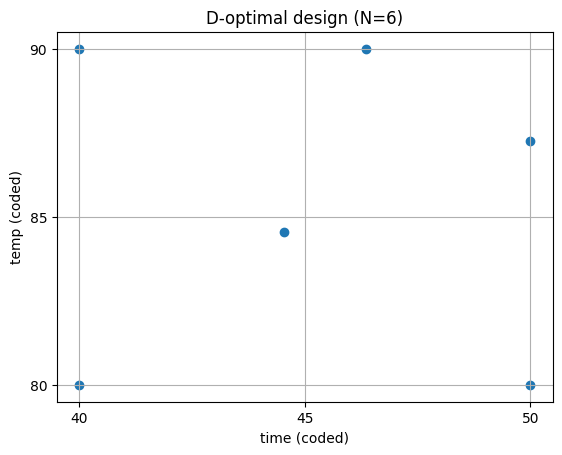

/usr/local/lib/python3.12/dist-packages/dexpy/optimal.py:114: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  original_value = design_point[f]
/usr/local/lib/python3.12/dist-packages/dexpy/optimal.py:122: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  design_point[f] = low + ((high - low) / (steps - 1)) * s
/usr/local/lib/python3.12/dist-packages/dexpy/optimal.py:135: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  design_point

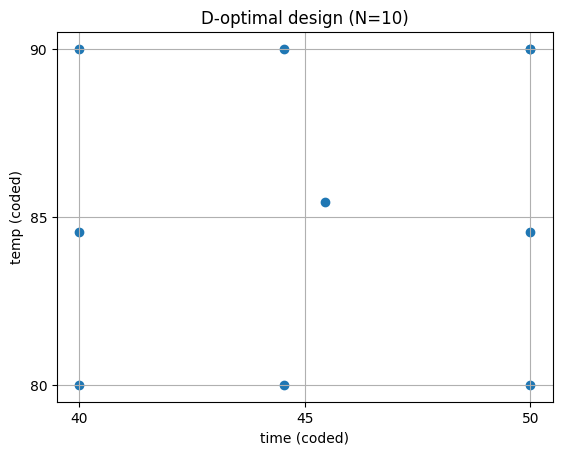

Antal duplicerade experiment: 1


,time,temp
0,1.000000,1.000000
1,1.000000,-0.090909
2,1.000000,1.000000
3,-1.000000,-1.000000
4,-1.000000,-0.090909
5,1.000000,-1.000000
6,-1.000000,1.000000
7,-0.090909,1.000000
8,-0.090909,-1.000000
9,0.090909,0.090909


In [ ]:
reaction_design = dexpy.optimal.build_optimal(2, run_count=6, order=ModelOrder.quadratic)
reaction_design.columns = ['time','temp']
reaction_design



actual_lows = {'time': 40, 'temp': 80}
actual_highs = {'time': 50, 'temp': 90}

dexpy.design.coded_to_actual(reaction_design, actual_lows, actual_highs)

X = reaction_design.to_numpy()
plt.figure()
plt.scatter(X[:,0], X[:,1])
plt.xlabel("time (coded)")
plt.ylabel("temp (coded)")
plt.xticks([-1,0,1], ["40","45","50"])
plt.yticks([-1,0,1], ["80","85","90"])
plt.grid(True)
plt.title("D-optimal design (N=6)")
plt.show()

X = reaction_design.to_numpy()
nrows = X.shape[0]

Z = np.c_[np.ones((nrows,1)), X]
Z = np.c_[Z, X[:,0]**2]
Z = np.c_[Z, X[:,1]**2]
Z = np.c_[Z, X[:,0]*X[:,1]]

det_val = np.linalg.det(Z.T @ Z)
det_val

reaction_design_10 = dexpy.optimal.build_optimal(2, run_count=10, order=ModelOrder.quadratic)
reaction_design_10.columns = ['time','temp']

X10 = reaction_design_10.to_numpy()

# plot
plt.figure()
plt.scatter(X10[:,0], X10[:,1])
plt.xlabel("time (coded)")
plt.ylabel("temp (coded)")
plt.xticks([-1,0,1], ["40","45","50"])
plt.yticks([-1,0,1], ["80","85","90"])
plt.grid(True)
plt.title("D-optimal design (N=10)")
plt.show()

# duplicates?
df10 = reaction_design_10.copy()
dups = df10.duplicated().sum()
print("Antal duplicerade experiment:", dups)
reaction_design_10


b2

In [ ]:
import numpy as np

X = [[-1,-1],[1,-1],[-1,1],[1,1],[0,0],[0,0],[0,0],[1,0],[-1,0],[0,1],[0,-1]]
log_y = np.log([13.65, 13.74, 15.48, 13.53, 17.38, 16.35, 16.41, 12.51, 15.17, 14.86, 11.85])

X = np.asarray(X, dtype=float)
log_y = np.asarray(log_y, dtype=float).reshape(-1,1)

print("X shape:", X.shape)
print("log_y shape:", log_y.shape)
print("X:\n", X)
print("log_y:\n", log_y[:5], "...")

# Bygg Z
x1 = X[:,0]
x2 = X[:,1]
n = X.shape[0]

Z = np.c_[
    np.ones((n,1)),         # 1
    x1.reshape(-1,1),       # x1
    x2.reshape(-1,1),       # x2
    (x1*x2).reshape(-1,1),  # x1x2
    (x1**2).reshape(-1,1),  # x1^2
    (x2**2).reshape(-1,1)   # x2^2
]

# OLS: w = (Z^T Z)^(-1) Z^T log_y
w_simulator = np.linalg.inv(Z.T @ Z) @ (Z.T @ log_y)

print("w_simulator =\n", w_simulator)

w_expected = np.array([
    [ 2.76275703],
    [-0.05347652],
    [ 0.05612545],
    [-0.03530280],
    [-0.06024905],
    [-0.09767266]
])

diff = w_simulator - w_expected
print("Max |diff|:", np.max(np.abs(diff)))
print("diff =\n", diff)

X shape: (11, 2)
log_y shape: (11, 1)
X:
 [[-1. -1.]
 [ 1. -1.]
 [-1.  1.]
 [ 1.  1.]
 [ 0.  0.]
 [ 0.  0.]
 [ 0.  0.]
 [ 1.  0.]
 [-1.  0.]
 [ 0.  1.]
 [ 0. -1.]]
log_y:
 [[2.61373952]
 [2.62031129]
 [2.73954887]
 [2.60490944]
 [2.85532012]] ...
w_simulator =
 [[ 2.76275703]
 [-0.05347652]
 [ 0.05612545]
 [-0.0353028 ]
 [-0.06024905]
 [-0.09767266]]
Max |diff|: 4.395403541135323e-09
diff =
 [[-1.47036294e-09]
 [-1.61621171e-09]
 [-4.39540354e-09]
 [ 2.21447042e-09]
 [-1.26321034e-09]
 [ 3.25253716e-09]]


b3

In [ ]:
!pip -q install dexpy
import dexpy.optimal
from dexpy.model import ModelOrder

d_opt = dexpy.optimal.build_optimal(2, run_count=6, order=ModelOrder.quadratic)
d_opt.columns = ["x1","x2"]
d_opt

Xnew = d_opt.to_numpy()
x1n = Xnew[:,0]
x2n = Xnew[:,1]
N = Xnew.shape[0]

Znew = np.c_[
    np.ones((N,1)),
    x1n.reshape(-1,1),
    x2n.reshape(-1,1),
    (x1n*x2n).reshape(-1,1),
    (x1n**2).reshape(-1,1),
    (x2n**2).reshape(-1,1)
]

det_val = np.linalg.det(Znew.T @ Znew)
print("Determinant |Z^T Z| =", det_val)

rng = np.random.default_rng(0)  # seed så du får reproducerbart resultat
sigma = 0.1

eps = rng.normal(loc=0.0, scale=sigma, size=(N,1))
logy_sim = Znew @ w_simulator + eps

print("Simulated log(y):\n", logy_sim)

v_D_optimal = np.linalg.inv(Znew.T @ Znew) @ (Znew.T @ logy_sim)
print("v_D_optimal =\n", v_D_optimal)

terms = ["w0","w1","w2","w12","w11","w22"]

compare = np.c_[w_simulator, v_D_optimal, (v_D_optimal - w_simulator), np.abs(v_D_optimal - w_simulator)]
print("Kolumner: [w_simulator, v_D_optimal, diff, |diff|]\n")
for i,t in enumerate(terms):
    print(f"{t:>3}:  {compare[i,0]: .6f}   {compare[i,1]: .6f}   {compare[i,2]: .6f}   {compare[i,3]: .6f}")

print("\nL2-norm |v-w| =", float(np.linalg.norm(v_D_optimal - w_simulator)))
print("Max |diff|  =", float(np.max(np.abs(v_D_optimal - w_simulator))))

Determinant |Z^T Z| = 264.567124771258
Simulated log(y):
 [[2.78993551]
 [2.73856935]
 [2.63092586]
 [2.75143104]
 [2.51861451]
 [2.56669566]]
v_D_optimal =
 [[ 2.74921048]
 [-0.08333096]
 [ 0.02717528]
 [-0.05121586]
 [-0.06652312]
 [-0.05670132]]
Kolumner: [w_simulator, v_D_optimal, diff, |diff|]

 w0:   2.762757    2.749210   -0.013547    0.013547
 w1:  -0.053477   -0.083331   -0.029854    0.029854
 w2:   0.056125    0.027175   -0.028950    0.028950
w12:  -0.035303   -0.051216   -0.015913    0.015913
w11:  -0.060249   -0.066523   -0.006274    0.006274
w22:  -0.097673   -0.056701    0.040971    0.040971

L2-norm |v-w| = 0.062322936990091844
Max |diff|  = 0.04097134000202729


/usr/local/lib/python3.12/dist-packages/dexpy/optimal.py:114: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  original_value = design_point[f]
/usr/local/lib/python3.12/dist-packages/dexpy/optimal.py:122: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  design_point[f] = low + ((high - low) / (steps - 1)) * s
/usr/local/lib/python3.12/dist-packages/dexpy/optimal.py:135: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  design_point